# Benchmark Trajectory Analysis

Analysis of coding benchmark trajectory.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Switch between agents by changing the file name:
#   "operations_stats_copilot.csv"  → copilot agent
#   "operations_stats_codex.csv"    → codex agent
CSV_PATH = "operations_stats_copilot.csv"
df = pd.read_csv(CSV_PATH)

# Coerce `resolved` to a clean boolean column.
_truthy = {"true", "True", "TRUE", True, 1, "1"}
df["resolved"] = df["resolved"].map(
    lambda v: True if v in _truthy
    else (False if pd.notna(v) and str(v).strip() != "" else np.nan)
)
_n_missing = int(df["resolved"].isna().sum())
if _n_missing:
    print(f"Dropping {_n_missing} rows with missing `resolved` status")
    df = df[df["resolved"].notna()].copy()
df["resolved"] = df["resolved"].astype(bool)

print(f"Source: {CSV_PATH}")
print(f"Shape: {df.shape}")
print(f"Resolved: {int(df['resolved'].sum())} / {len(df)}  ({df['resolved'].mean():.1%})")

Dropping 6 rows with missing `resolved` status
Source: operations_stats_copilot.csv
Shape: (2468, 24)
Resolved: 1552 / 2468  (62.9%)


## Metric configuration

Curated list of non-redundant metrics covering codebase size, quality, scale, exploration, and efficiency.

In [2]:
METRICS = [
    # Codebase size
    "source_code_files", "source_code_tokens",
    # Quality
    "write_recall", "write_precision",
    "read_recall", "read_precision",
    # Scale of work
    "total_operations", "total_reads", "total_writes",
    # Exploration breadth
    "unique_files_read", "unique_files_written", "unique_dirs", "max_depth",
    # Efficiency / behaviour
    "first_write_at", "reread_rate", "churn_rate", "conversion_rate",
    # Navigation
    "first_correct_read", "first_correct_write",
    # Sub-agents
    "subagent_count",
]
METRICS = [m for m in METRICS if m in df.columns]

# Codebase size threshold for the stratified table (None = median).
SIZE_THRESHOLD = 10_000_000

METRIC_DESC = {
    "source_code_files":   "Number of source code files in the repository",
    "source_code_tokens":  "Total tokens across all source code files (proxy for codebase size)",
    "write_recall":        "Fraction of ground-truth files that the agent actually edited",
    "write_precision":     "Fraction of agent-edited files that are in the ground truth",
    "read_recall":         "Fraction of ground-truth files that the agent read",
    "read_precision":      "Fraction of agent-read files that are in the ground truth",
    "total_operations":    "Total number of read + write + explore operations",
    "total_reads":         "Total file-read operations (including re-reads)",
    "total_writes":        "Total file-write operations (including re-writes)",
    "unique_files_read":   "Number of distinct files the agent read at least once",
    "unique_files_written": "Number of distinct files the agent wrote to at least once",
    "unique_dirs":         "Number of distinct directories the agent touched",
    "max_depth":           "Deepest directory level the agent reached (1 = repo root)",
    "first_write_at":      "Operation index of the agent's first write",
    "reread_rate":         "Fraction of reads that are re-reads of already-seen files",
    "churn_rate":          "Fraction of writes that overwrite a previously written file",
    "conversion_rate":     "Fraction of ground-truth files that were read before being written",
    "first_correct_read":  "Operation index when the agent first reads a ground-truth file",
    "first_correct_write": "Operation index when the agent first writes a ground-truth file",
    "subagent_count":      "Number of sub-agents spawned during the task",
}

desc_df = pd.DataFrame([{"metric": m, "description": METRIC_DESC.get(m, "")} for m in METRICS])
print(f"{len(METRICS)} metrics configured\n")
display(desc_df.style.hide(axis="index").set_properties(**{"text-align": "left"}))

20 metrics configured



metric,description
source_code_files,Number of source code files in the repository
source_code_tokens,Total tokens across all source code files (proxy for codebase size)
write_recall,Fraction of ground-truth files that the agent actually edited
write_precision,Fraction of agent-edited files that are in the ground truth
read_recall,Fraction of ground-truth files that the agent read
read_precision,Fraction of agent-read files that are in the ground truth
total_operations,Total number of read + write + explore operations
total_reads,Total file-read operations (including re-reads)
total_writes,Total file-write operations (including re-writes)
unique_files_read,Number of distinct files the agent read at least once


## 1 · Stratified 2×2 Table (Small / Large Codebase × Resolved / Unresolved)

Mean of each metric per cell. `n` is the number of instances in that cell. Codebase size is split on `source_code_tokens`.

In [3]:
def build_stratified_table(data: pd.DataFrame, threshold: float = None) -> pd.DataFrame:
    if threshold is None:
        threshold = data["source_code_tokens"].median()
    data = data.copy()
    data["codebase_size"] = np.where(data["source_code_tokens"] <= threshold, "small", "large")
    data["status"] = np.where(data["resolved"], "resolved", "unresolved")
    tbl = data.groupby(["codebase_size", "status"])[METRICS].mean().round(3)
    counts = data.groupby(["codebase_size", "status"]).size().rename("n")
    tbl.insert(0, "n", counts)
    return tbl


median_threshold = df["source_code_tokens"].median()
print("═" * 60)
print(f"MEDIAN THRESHOLD ({median_threshold:,.0f} tokens)")
print(f"  Small: ≤ {median_threshold:,.0f}  ({(df['source_code_tokens'] <= median_threshold).sum()} instances)")
print(f"  Large: > {median_threshold:,.0f}  ({(df['source_code_tokens'] > median_threshold).sum()} instances)")
print("═" * 60)
with pd.option_context("display.float_format", "{:.2f}".format):
    display(build_stratified_table(df, threshold=median_threshold).T)

if SIZE_THRESHOLD is not None and SIZE_THRESHOLD != median_threshold:
    print(f"\n{'═' * 60}")
    print(f"CUSTOM THRESHOLD ({SIZE_THRESHOLD:,.0f} tokens)")
    print(f"  Small: ≤ {SIZE_THRESHOLD:,.0f}  ({(df['source_code_tokens'] <= SIZE_THRESHOLD).sum()} instances)")
    print(f"  Large: > {SIZE_THRESHOLD:,.0f}  ({(df['source_code_tokens'] > SIZE_THRESHOLD).sum()} instances)")
    print("═" * 60)
    with pd.option_context("display.float_format", "{:.2f}".format):
        display(build_stratified_table(df, threshold=SIZE_THRESHOLD).T)

════════════════════════════════════════════════════════════
MEDIAN THRESHOLD (2,468,839 tokens)
  Small: ≤ 2,468,839  (1235 instances)
  Large: > 2,468,839  (1233 instances)
════════════════════════════════════════════════════════════


codebase_size             large                  small           
status                 resolved  unresolved   resolved unresolved
n                        808.00      425.00     744.00     491.00
source_code_files       3916.76     7711.68     700.01     661.60
source_code_tokens   9301826.12 22607449.25 1089747.94 1004613.35
write_recall               0.90        0.68       0.73       0.69
write_precision            0.69        0.56       0.66       0.58
read_recall                0.92        0.75       0.78       0.75
read_precision             0.48        0.34       0.44       0.34
total_operations          35.54       62.31      45.16      65.01
total_reads               18.02       31.29      21.66      31.84
total_writes               4.34        7.58       7.20       9.79
unique_files_read          4.83        9.15       7.20      11.16
unique_files_written       2.20        3.49       3.57       4.93
unique_dirs                7.78       14.70       7.84      10.47
max_depth                  3.84        5.50       3.19       3.64
first_write_at            22.47       40.38      30.07      43.89
reread_rate                0.58        0.60       0.56       0.58
churn_rate                 0.30        0.41       0.41       0.43
conversion_rate            0.94        0.77       0.90       0.84
first_correct_read         4.28        5.85       3.60       4.46
first_correct_write       23.20       43.50      30.65      46.70
subagent_count             0.27        0.51       0.46       0.69


════════════════════════════════════════════════════════════
CUSTOM THRESHOLD (10,000,000 tokens)
  Small: ≤ 10,000,000  (2047 instances)
  Large: > 10,000,000  (421 instances)
════════════════════════════════════════════════════════════


codebase_size              large                  small           
status                  resolved  unresolved   resolved unresolved
n                         213.00      208.00    1339.00     708.00
source_code_files        8486.69    12839.97    1402.45    1315.81
source_code_tokens   23137655.64 40764572.49 2537959.16 2291525.43
write_recall                0.84        0.66       0.82       0.70
write_precision             0.72        0.55       0.67       0.58
read_recall                 0.88        0.68       0.85       0.77
read_precision              0.47        0.29       0.46       0.35
total_operations           45.88       75.53      39.24      60.30
total_reads                22.85       37.88      19.27      29.73
total_writes                4.66        8.38       5.88       8.88
unique_files_read           6.88       11.02       5.83       9.99
unique_files_written        2.35        3.73       2.94       4.42
unique_dirs                12.63       19.80       7.04      10.27
max_depth                   5.31        7.13       3.25       3.73
first_write_at             29.85       50.41      25.52      39.87
reread_rate                 0.59        0.61       0.57       0.59
churn_rate                  0.33        0.44       0.36       0.42
conversion_rate             0.92        0.74       0.92       0.82
first_correct_read          7.41        7.47       3.40       4.45
first_correct_write        32.02       52.57      25.72      43.13
subagent_count              0.31        0.61       0.37       0.61

## 2 · Statistical Tests — Resolved vs Unresolved

Mann-Whitney U test (non-parametric, robust to skewed distributions) per metric.

| Column | Meaning |
|---|---|
| `mean_resolved` / `mean_unresolved` | Group means (direction of difference). |
| `diff` | `mean_resolved − mean_unresolved`. |
| `U_statistic` | Raw Mann-Whitney U value. |
| `p_value` | Probability the difference arose by chance. |
| `rank_biserial_r` | Effect size in [−1, +1]. <0.1 negligible, 0.1–0.3 small, 0.3–0.5 medium, >0.5 large. Positive = unresolved ranks higher. |
| `significant` | `***` p<0.001, `**` p<0.01, `*` p<0.05. |

In [4]:
def mann_whitney_table(data: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    resolved = data[data["resolved"]]
    unresolved = data[~data["resolved"]]
    rows = []
    for m in metrics:
        a = resolved[m].dropna()
        b = unresolved[m].dropna()
        if len(a) < 5 or len(b) < 5:
            continue
        u_stat, p_val = stats.mannwhitneyu(a, b, alternative="two-sided")
        r_effect = 1 - (2 * u_stat) / (len(a) * len(b))
        rows.append({
            "metric": m,
            "mean_resolved": a.mean(),
            "mean_unresolved": b.mean(),
            "diff": a.mean() - b.mean(),
            "U_statistic": int(u_stat),
            "p_value": p_val,
            "rank_biserial_r": r_effect,
            "significant": "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "")),
        })
    result = pd.DataFrame(rows).sort_values("p_value")
    for col in ["mean_resolved", "mean_unresolved", "diff", "rank_biserial_r"]:
        result[col] = result[col].apply(lambda x: f"{x:.4f}")
    result["p_value"] = result["p_value"].map(lambda x: f"{x:.2e}")
    return result.reset_index(drop=True)


print("Overall — Mann-Whitney U (resolved vs unresolved)")
with pd.option_context("display.float_format", "{:.4f}".format):
    display(mann_whitney_table(df, METRICS))

for bench, bdf in df.groupby("benchmark"):
    print(f"\n{bench} — Mann-Whitney U")
    with pd.option_context("display.float_format", "{:.4f}".format):
        display(mann_whitney_table(bdf, METRICS))

Overall — Mann-Whitney U (resolved vs unresolved)


,metric,mean_resolved,mean_unresolved,diff,U_statistic,p_value,rank_biserial_r,significant
0,unique_files_read,5.9697,10.2282,-4.2584,442645,7.85e-56,0.3773,***
1,total_operations,40.1508,63.7566,-23.6058,461632,4.27e-48,0.3506,***
2,first_correct_write,26.6311,45.2400,-18.6089,401654,5.29e-46,0.3545,***
3,unique_files_written,2.8563,4.2653,-1.4090,475626,4.91e-45,0.3309,***
4,total_writes,5.7126,8.7686,-3.0559,472954,2.43e-44,0.3346,***
5,total_reads,19.7648,31.5808,-11.8160,475452,3.98e-43,0.3311,***
6,unique_dirs,7.8067,12.4345,-4.6278,476651,6.82e-43,0.3294,***
7,first_write_at,26.1095,42.2642,-16.1547,476502,9.55e-43,0.3296,***
8,write_recall,0.8232,0.6884,0.1348,835931,9.73e-32,-0.2596,***
9,conversion_rate,0.9194,0.8051,0.1143,803136,3.96e-31,-0.2102,***



swebench-pro — Mann-Whitney U


,metric,mean_resolved,mean_unresolved,diff,U_statistic,p_value,rank_biserial_r,significant
0,unique_files_read,8.1966,12.1883,-3.9917,138604,1.67e-23,0.3228,***
1,total_operations,53.5785,72.2660,-18.6875,150486,2.86e-16,0.2648,***
2,read_precision,0.4228,0.3220,0.1008,226641,5.58e-16,-0.2702,***
3,first_correct_write,37.2908,52.3888,-15.0980,129766,7.36e-16,0.2701,***
4,unique_dirs,9.1796,12.2971,-3.1174,152155,2.03e-15,0.2566,***
5,total_reads,25.7496,35.4180,-9.6683,152306,2.67e-15,0.2559,***
6,first_write_at,36.2008,49.7358,-13.5349,152305,2.68e-15,0.2559,***
7,unique_files_written,4.0127,5.1641,-1.1513,156043,1.10e-13,0.2376,***
8,max_depth,3.5092,4.0794,-0.5703,162338,4.20e-11,0.2069,***
9,total_writes,8.5092,10.8463,-2.3371,162267,1.42e-10,0.2072,***



swebench-verified — Mann-Whitney U


,metric,mean_resolved,mean_unresolved,diff,U_statistic,p_value,rank_biserial_r,significant
0,write_recall,0.9410,0.7442,0.1968,112765,1.76e-25,-0.2784,***
1,read_recall,0.9729,0.8877,0.0852,102671,2.23e-16,-0.1640,***
2,conversion_rate,0.9406,0.7935,0.1471,105237,3.48e-15,-0.1931,***
3,write_precision,0.6807,0.4963,0.1844,115703,2.31e-14,-0.3118,***
4,total_writes,3.2542,4.2130,-0.9588,63885,9.72e-11,0.2757,***
5,total_operations,25.9505,35.4000,-9.4495,64307,4.34e-10,0.2709,***
6,unique_files_written,1.8409,2.3913,-0.5504,66809,2.26e-09,0.2426,***
7,unique_files_read,3.4081,4.4826,-1.0745,67267,2.79e-08,0.2374,***
8,total_reads,13.2438,18.0478,-4.8040,67545,6.58e-08,0.2342,***
9,first_correct_write,16.0202,24.0249,-8.0047,57588,6.10e-07,0.2288,***



swebench-xl-v1 — Mann-Whitney U


,metric,mean_resolved,mean_unresolved,diff,U_statistic,p_value,rank_biserial_r,significant
0,total_writes,4.5385,7.3178,-2.7793,2465,1.84e-06,0.4092,***
1,source_code_tokens,34938853.5000,61928087.8972,-26989234.3972,2722,5.51e-05,0.3477,***
2,unique_files_written,2.3590,3.4299,-1.0709,2770,5.53e-05,0.3361,***
3,read_recall,0.8084,0.6705,0.1380,5237,1.64e-03,-0.2551,**
4,total_operations,58.0769,78.6636,-20.5866,3044,1.70e-03,0.2705,**
5,total_reads,29.6410,39.9065,-10.2655,3070,2.18e-03,0.2642,**
6,write_recall,0.7175,0.5672,0.1503,5229,2.26e-03,-0.2531,**
7,first_write_at,35.7564,48.3084,-12.5520,3135,3.93e-03,0.2486,**
8,reread_rate,0.5501,0.6311,-0.0809,3176,5.61e-03,0.2388,**
9,write_precision,0.6648,0.5467,0.1181,5134,5.70e-03,-0.2304,**


## 3 · Logistic Regression — Which Metrics Predict Resolution?

All metrics standardised, fit jointly with L2 regularisation. Coefficients are directly comparable: positive → associated with resolution, negative → associated with failure. Codebase-size metrics excluded so only behavioural predictors remain. Accuracy is reported on the training set as a sanity check.

Logistic regression accuracy: 70.1%  (n=2279)


metric,coefficient
first_correct_write,-0.5189
unique_files_read,-0.3924
first_correct_read,+0.2756
conversion_rate,+0.2628
unique_files_written,-0.2556
read_recall,+0.2548
max_depth,-0.2260
total_reads,+0.2174
subagent_count,+0.1870
first_write_at,+0.1695


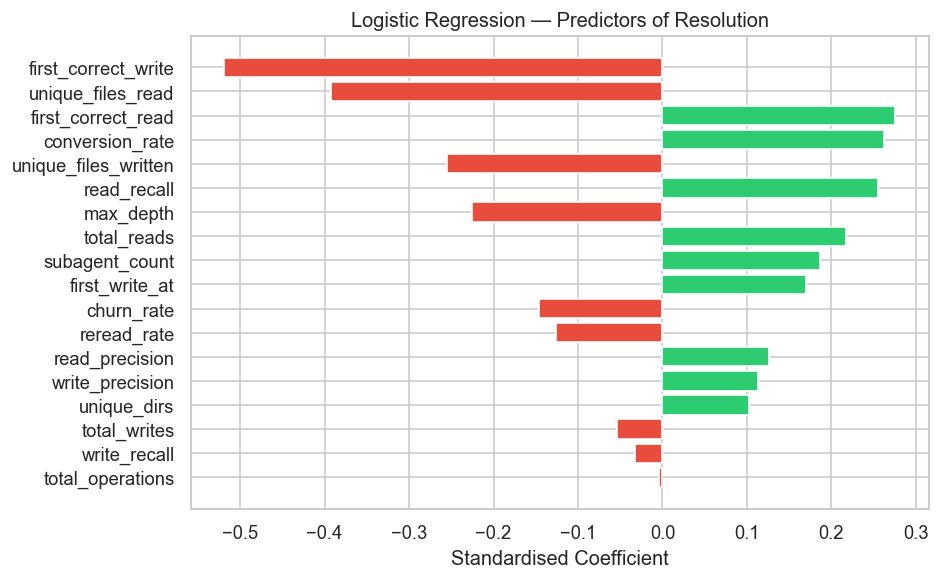

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

PRED_METRICS = [m for m in METRICS if m not in ("source_code_files", "source_code_tokens")]

sub = df[PRED_METRICS + ["resolved"]].dropna()
X = sub[PRED_METRICS].values
y = sub["resolved"].astype(int).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=2000, penalty="l2", C=1.0, solver="lbfgs")
lr.fit(X_scaled, y)

coef_df = (
    pd.DataFrame({"metric": PRED_METRICS, "coefficient": lr.coef_[0]})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)
coef_df["coefficient"] = coef_df["coefficient"].round(4)
print(f"Logistic regression accuracy: {lr.score(X_scaled, y):.1%}  (n={len(sub)})")
display(coef_df.style.format({"coefficient": "{:+.4f}"}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in coef_df["coefficient"]]
ax.barh(coef_df["metric"], coef_df["coefficient"], color=colors)
ax.set_xlabel("Standardised Coefficient")
ax.set_title("Logistic Regression — Predictors of Resolution")
ax.invert_yaxis()
plt.tight_layout()
plt.show()